## Pairwise age comparison (UTKFace)

Questo notebook carica il modello `ResNetPairwiseAge` e confronta due immagini restituendo:
- probabilità `P(prima più giovane)` / `P(prima più vecchia)`
- `confidence = max(probabilità)`
- output “INCERTO (possibile coetanei)” se la confidence è sotto una soglia


In [8]:
import os
from typing import cast

import torch
from PIL import Image
import torchvision.transforms as T

from model import ResNetPairwiseAge

# Preview immagini: prova matplotlib se presente, altrimenti fallback su IPython.display
try:
    import matplotlib.pyplot as plt  # type: ignore
except ModuleNotFoundError:
    plt = None  # type: ignore


In [9]:
def get_transform():
    return T.Compose(
        [
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )


def compare_two_faces(
    img_path1: str,
    img_path2: str,
    ckpt_path: str = "pairwise_resnet.pt",
    *,
    uncertain_thr: float = 0.60,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = ResNetPairwiseAge(pretrained=False).to(device)
    state_dict = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    transform = get_transform()

    img1_t = cast(torch.Tensor, transform(Image.open(img_path1).convert("RGB")))
    img2_t = cast(torch.Tensor, transform(Image.open(img_path2).convert("RGB")))
    img1 = img1_t.unsqueeze(0).to(device)
    img2 = img2_t.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img1, img2)
        probs = torch.softmax(logits, dim=1)
        p_young = float(probs[0, 0].item())
        p_old = float(probs[0, 1].item())

    pred = 0 if p_young >= p_old else 1
    conf = max(p_young, p_old)

    print(f"P(prima più giovane) = {p_young:.3f}")
    print(f"P(prima più vecchia) = {p_old:.3f}")
    print(f"Confidence = {conf:.3f}")

    if conf < uncertain_thr:
        verdict = "INCERTO (possibile coetanei o differenza piccola)"
    elif pred == 0:
        verdict = "PRIMA più giovane della SECONDA"
    else:
        verdict = "PRIMA più vecchia della SECONDA"

    print(verdict)

    return {
        "p_young": p_young,
        "p_old": p_old,
        "confidence": conf,
        "pred": pred,
        "verdict": verdict,
    }


matplotlib non è installato: mostro le immagini una sotto l'altra.


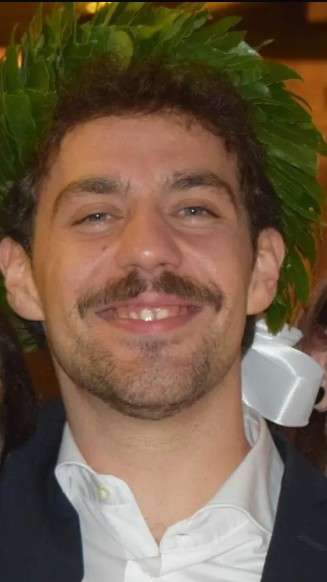

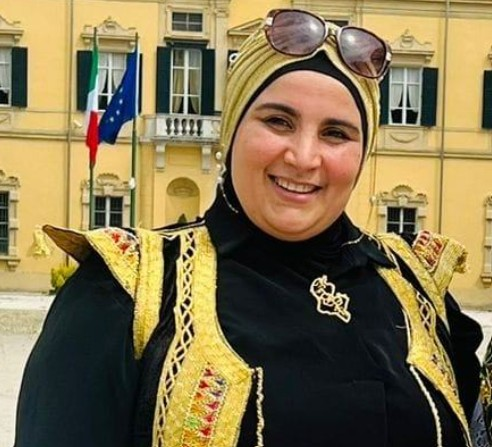

In [ ]:
# Preview immagini (controllo veloce dei path)

img1_preview = Image.open(os.path.join("data", "UTKFace", "chayouba.jpg")).convert("RGB")
img2_preview = Image.open(os.path.join("data", "UTKFace", "mrachayouba.jpg")).convert("RGB")

if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img1_preview)
    axes[0].set_title("Immagine 1")
    axes[0].axis("off")

    axes[1].imshow(img2_preview)
    axes[1].set_title("Immagine 2")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    from IPython.display import display

    print("matplotlib non è installato: mostro le immagini una sotto l'altra.")
    display(img1_preview)
    display(img2_preview)


In [13]:
# Demo: imposta qui i path delle due immagini
img1_path = os.path.join("data", "UTKFace", "foto_flavio.jpg")
img2_path = os.path.join("data", "UTKFace", "foto_arbia.jpg")

_ = compare_two_faces(img1_path, img2_path, "pairwise_resnet.pt", uncertain_thr=0.60)


/home/tchelmi/miniconda3/envs/utk_pair/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tchelmi/miniconda3/envs/utk_pair/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_174474/3068246364.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weigh

P(prima più giovane) = 0.684
P(prima più vecchia) = 0.316
Confidence = 0.684
PRIMA più giovane della SECONDA


In [15]:
import os
from typing import cast
import torch
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

# Import dei tre modelli addestrati (Early Fusion, Regressore, MLP)
from model import ResNetPairwiseAge
#from age_regression_model import ResNetAgeRegressor
#from pair_mlp_model import PairMLP

from age_regression_model import AgeResNet18, AgeFeatureExtractor
from pair_mlp_model import PairwiseAgeMLP


def get_transform():
    return T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def final_arena_inference(
    img_path1: str, 
    img_path2: str, 
    ckpt_method1: str = "pairwise_resnet.pt",
    ckpt_regressor: str = "age_resnet18.pt",
    ckpt_mlp: str = "pairwise_mlp.pt",
    uncertain_thr: float = 0.60
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    transform = get_transform()
    
    # Caricamento e conversione immagini
    img1_pil = Image.open(img_path1).convert("RGB")
    img2_pil = Image.open(img_path2).convert("RGB")
    
    img1_t = cast(torch.Tensor, transform(img1_pil)).unsqueeze(0).to(device)
    img2_t = cast(torch.Tensor, transform(img2_pil)).unsqueeze(0).to(device)

    # ----------------------------------------------------
    # METODO 1: EARLY FUSION (6 Canali)
    # ----------------------------------------------------
    model1 = ResNetPairwiseAge(pretrained=False).to(device) 
    model1.load_state_dict(torch.load(ckpt_method1, map_location=device, weights_only=True))
    model1.eval()

    with torch.no_grad():
        logits1 = model1(img1_t, img2_t)
        probs1 = torch.softmax(logits1, dim=1)
        p_young = probs1[0, 0].item()
        p_old = probs1[0, 1].item()

    pred1 = 0 if p_young >= p_old else 1
    conf1 = max(p_young, p_old)

    if conf1 < uncertain_thr:
        verdict1 = f"INCERTO (Coetanei) - Conf: {conf1*100:.1f}%"
        color1 = "#d97706"  # Arancione scuro
    elif pred1 == 0:
        verdict1 = f"IMMAGINE 1 è più GIOVANE ({conf1*100:.1f}%)"
        color1 = "#16a34a"  # Verde brillante
    else:
        verdict1 = f"IMMAGINE 1 è più VECCHIA ({conf1*100:.1f}%)"
        color1 = "#dc2626"  # Rosso

#  # ----------------------------------------------------
#     # METODO 2: LATE FUSION / SIAMESE (Regressore + MLP)
#     # ----------------------------------------------------
#     # Usa AgeResNet18 al posto di ResNetAgeRegressor ed esplicita pretrained=False
#     regressor = AgeResNet18(pretrained=False).to(device)
#     regressor.load_state_dict(torch.load(ckpt_regressor, map_location=device, weights_only=True))
#     regressor.eval()

#     mlp = PairwiseAgeMLP(feature_dim=2).to(device)
#     mlp.load_state_dict(torch.load(ckpt_mlp, map_location=device, weights_only=True))
#     mlp.eval()

#     with torch.no_grad():
#         # Step 1: Estrazione dell'età indipendente (Valori scalari continui)
#         age1 = regressor(img1_t).item()
#         age2 = regressor(img2_t).item()
        
#         # Step 2: L'MLP riceve in input i due numeri dell'età ed elabora il verdetto
#         feats = torch.tensor([[age1, age2]], dtype=torch.float32).to(device)
#         logits2 = mlp(feats)
#         probs2 = torch.softmax(logits2, dim=1)
        
# ----------------------------------------------------
# METODO 2: LATE FUSION / SIAMESE (Feature Extractor + MLP)
# ----------------------------------------------------
    # 1. Carichiamo la ResNet base
    base_regressor = AgeResNet18(pretrained=False).to(device)
    base_regressor.load_state_dict(torch.load(ckpt_regressor, map_location=device, weights_only=True))
    base_regressor.eval()
    
    # 2. CALCOLIAMO LE ETÀ SUBITO (Prima di modificare la rete!)
    with torch.no_grad():
        age1 = base_regressor(img1_t).item()
        age2 = base_regressor(img2_t).item()

    # 3. Ora la passiamo al Feature Extractor (che rimuove l'ultimo layer)
    feature_extractor = AgeFeatureExtractor(pretrained_backbone=base_regressor).to(device)
    feature_extractor.eval()

    # 4. Inizializziamo l'MLP
    mlp = PairwiseAgeMLP(feature_dim=512).to(device)
    mlp.load_state_dict(torch.load(ckpt_mlp, map_location=device, weights_only=True))
    mlp.eval()

    with torch.no_grad():
        # Estraiamo i vettori di feature da 512 elementi ciascuno
        feat1 = feature_extractor(img1_t) # Shape: [1, 512]
        feat2 = feature_extractor(img2_t) # Shape: [1, 512]
        
        # Passiamo i due vettori all'MLP
        logits2 = mlp(feat1, feat2)
        probs2 = torch.softmax(logits2, dim=1)
        
    pred2 = torch.argmax(probs2, dim=1).item()
    conf2 = torch.max(probs2).item()
    
    if pred2 == 0:
        verdict2 = f"IMMAGINE 1 è più GIOVANE ({conf2*100:.1f}%)"
        color2 = "#16a34a"
    else:
        verdict2 = f"IMMAGINE 1 è più VECCHIA ({conf2*100:.1f}%)"
        color2 = "#dc2626"

    # ----------------------------------------------------
    # PLOTTING OVERLAY (LMDX User Interface)
    # ----------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(11, 6))
    
    # Immagine 1
    axes[0].imshow(img1_pil)
    axes[0].axis("off")
    axes[0].set_title(f"SOGGETTO 1\nEtà Stimata (M2): {age1:.1f} anni", fontsize=12, fontweight='bold', pad=10)
    
    # Immagine 2
    axes[1].imshow(img2_pil)
    axes[1].axis("off")
    axes[1].set_title(f"SOGGETTO 2\nEtà Stimata (M2): {age2:.1f} anni", fontsize=12, fontweight='bold', pad=10)
    
    # Visualizzazione dei verdetti sotto forma di banner colorati stilosi
    fig.text(0.5, 0.14, f"Approccio 1 (Early Fusion 6-Ch): {verdict1}", 
             ha="center", va="center", fontsize=11, color="white", fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.6", facecolor=color1, edgecolor="none"))
             
    fig.text(0.5, 0.04, f"Approccio 2 (Siamese ResNet+MLP): {verdict2}", 
             ha="center", va="center", fontsize=11, color="white", fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.6", facecolor=color2, edgecolor="none"))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.26)
    plt.show()

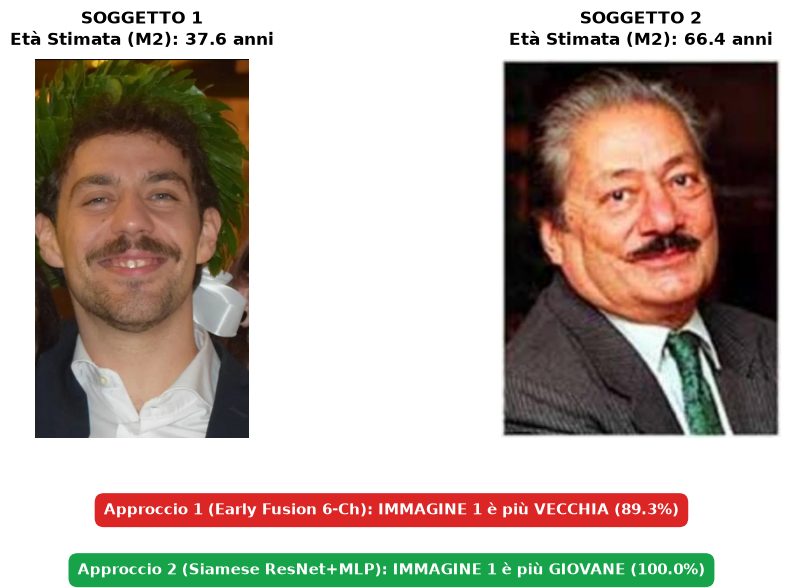

In [21]:
# Modifica qui i nomi dei file per testare coppie diverse
img1_name = "foto_flavio.jpg"
img2_name = "58_0_0_20170117191847355.jpg"

img1_path = os.path.join("data", "UTKFace", img1_name)
img2_path = os.path.join("data", "UTKFace", img2_name)

# Esecuzione dell'arena competitiva
final_arena_inference(img1_path, img2_path, uncertain_thr=0.60)

### Note

- Se vuoi meno “INCERTO”, abbassa `uncertain_thr` (es. `0.55`). Se vuoi più “INCERTO”, alzalo (es. `0.65`).
- Se ti dà warning su `pretrained`/`torch.load`, possiamo aggiornare a `weights=` e `weights_only=True` in base alla versione di Torch/Torchvision che usi.
